In [1]:
pip install pandas numpy matplotlib seaborn

In [2]:
from google.colab import files
uploaded = files.upload()

Saving ncr_ride_bookings.csv to ncr_ride_bookings.csv


In [3]:
import pandas as pd

df = pd.read_csv("ncr_ride_bookings.csv")
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M:%S')

In [5]:
df['hour'] = df['Time'].dt.hour

In [6]:
df.isnull().sum()

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [7]:
df['Driver Cancellation Reason'].fillna("No Cancellation", inplace=True)

/tmp/ipykernel_4999/1207298488.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Driver Cancellation Reason'].fillna("No Cancellation", inplace=True)


In [8]:
df['Reason for cancelling by Customer'].fillna("No Cancellation", inplace=True)

/tmp/ipykernel_4999/26373718.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Reason for cancelling by Customer'].fillna("No Cancellation", inplace=True)


In [9]:
df['Driver Ratings'].fillna(df['Driver Ratings'].mean(), inplace=True)
df['Customer Rating'].fillna(df['Customer Rating'].mean(), inplace=True)

/tmp/ipykernel_4999/1329053411.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Driver Ratings'].fillna(df['Driver Ratings'].mean(), inplace=True)
/tmp/ipykernel_4999/1329053411.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

In [10]:
df['driver_cancelled'] = df['Cancelled Rides by Driver'].apply(lambda x: 1 if x == 1 else 0)

In [11]:
df['customer_cancelled'] = df['Cancelled Rides by Customer'].apply(lambda x: 1 if x == 1 else 0)

In [12]:
df['is_cancelled'] = df['Booking Status'].apply(lambda x: 1 if x == 'Cancelled' else 0)

In [13]:
df['peak_hour'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 21) else 0)

In [14]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,driver_cancelled,customer_cancelled,is_cancelled,peak_hour
0,2024-03-23,1900-01-01 12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,4.230992,4.404584,NaN,12,0,0,0,0
1,2024-11-29,1900-01-01 18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,237.0,5.73,4.230992,4.404584,UPI,18,0,0,0,1
2,2024-08-23,1900-01-01 08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,627.0,13.58,4.900000,4.900000,Debit Card,8,0,0,0,1
3,2024-10-21,1900-01-01 17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,416.0,34.02,4.600000,5.000000,UPI,17,0,0,0,1
4,2024-09-16,1900-01-01 22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,737.0,48.21,4.100000,4.300000,UPI,22,0,0,0,0


In [15]:
total_rides = len(df)
cancelled = df['is_cancelled'].sum()

print("Cancellation Rate:", (cancelled / total_rides) * 100)

Cancellation Rate: 0.0


In [16]:
df['Booking Status'].value_counts()

,count
Booking Status,
Completed,93000
Cancelled by Driver,27000
No Driver Found,10500
Cancelled by Customer,10500
Incomplete,9000


In [17]:
df['is_cancelled'] = df['Booking Status'].apply(
    lambda x: 1 if 'cancel' in str(x).lower() else 0
)

In [18]:
total_rides = len(df)
cancelled = df['is_cancelled'].sum()

print("Cancellation Rate:", (cancelled / total_rides) * 100)

Cancellation Rate: 25.0


In [19]:
df['driver_cancelled'] = df['Driver Cancellation Reason'].apply(
    lambda x: 0 if x == "No Cancellation" else 1
)

In [20]:
df['customer_cancelled'] = df['Reason for cancelling by Customer'].apply(
    lambda x: 0 if x == "No Cancellation" else 1
)

In [21]:
driver_cancel = df['driver_cancelled'].sum()
customer_cancel = df['customer_cancelled'].sum()

print("Driver Cancel:", driver_cancel)
print("Customer Cancel:", customer_cancel)

Driver Cancel: 27000
Customer Cancel: 10500


In [22]:
total_cancel = driver_cancel + customer_cancel

print("Driver %:", (driver_cancel / total_cancel) * 100)
print("Customer %:", (customer_cancel / total_cancel) * 100)

Driver %: 72.0
Customer %: 28.000000000000004


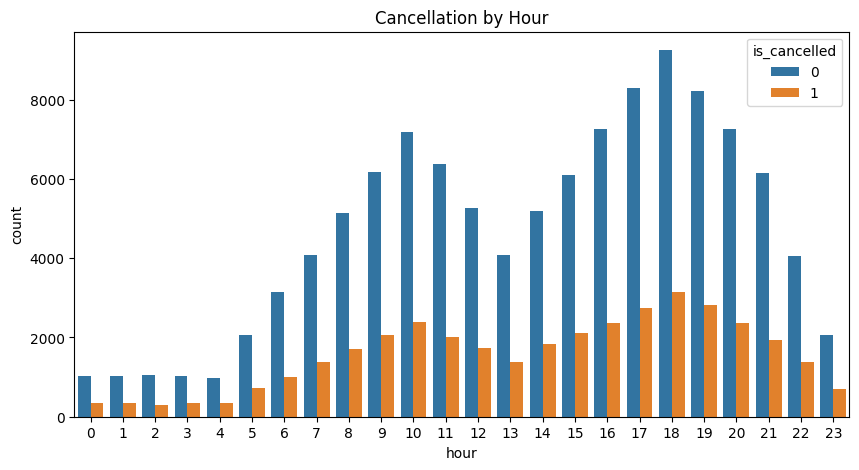

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='is_cancelled', data=df)
plt.title("Cancellation by Hour")
plt.show()

In [24]:
df['is_cancelled'].value_counts()

,count
is_cancelled,
0,112500
1,37500


In [25]:
completed = df[df['is_cancelled'] == 0]
cancelled = df[df['is_cancelled'] == 1]

In [26]:
print("Completed rides distance:")
print(completed['Ride Distance'].describe())

print("\nCancelled rides distance:")
print(cancelled['Ride Distance'].describe())

Completed rides distance:
count    102000.000000
mean         24.637012
std          14.002138
min           1.000000
25%          12.460000
50%          23.720000
75%          36.820000
max          50.000000
Name: Ride Distance, dtype: float64

Cancelled rides distance:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Ride Distance, dtype: float64


In [27]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'hour',
       'driver_cancelled', 'customer_cancelled', 'is_cancelled', 'peak_hour'],
      dtype='object')

In [28]:
df['is_cancelled'].dtype

dtype('int64')

In [29]:
print("Cancelled:", len(cancelled))
print("Completed:", len(completed))

Cancelled: 37500
Completed: 112500


In [30]:
df[df['is_cancelled'] == 1].head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,hour,driver_cancelled,customer_cancelled,is_cancelled,peak_hour
12,2024-06-25,1900-01-01 22:44:15,"""CNR4386945""",Cancelled by Driver,"""CID5543520""",eBike,Patel Chowk,Kherki Daula Toll,4.6,NaN,...,NaN,NaN,4.230992,4.404584,NaN,22,1,0,1,0
17,2024-12-15,1900-01-01 15:08:25,"""CNR6739317""",Cancelled by Driver,"""CID8682675""",Go Sedan,Vinobapuri,GTB Nagar,6.0,NaN,...,NaN,NaN,4.230992,4.404584,NaN,15,1,0,1,0
18,2024-11-24,1900-01-01 09:07:10,"""CNR6126048""",Cancelled by Customer,"""CID1060329""",eBike,Kashmere Gate,Anand Vihar,12.4,NaN,...,NaN,NaN,4.230992,4.404584,NaN,9,0,1,1,1
19,2024-05-24,1900-01-01 19:53:57,"""CNR9465840""",Cancelled by Driver,"""CID9046501""",eBike,Pitampura,Rajiv Nagar,10.3,NaN,...,NaN,NaN,4.230992,4.404584,NaN,19,1,0,1,1
26,2024-01-26,1900-01-01 09:44:00,"""CNR3614535""",Cancelled by Driver,"""CID2507102""",Auto,Cyber Hub,Saket,11.5,NaN,...,NaN,NaN,4.230992,4.404584,NaN,9,1,0,1,1


In [31]:
df[df['is_cancelled'] == 1]['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
No Cancellation,10500
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


In [32]:
df[df['is_cancelled'] == 1]['Reason for cancelling by Customer'].value_counts()

,count
Reason for cancelling by Customer,
No Cancellation,27000
Wrong Address,2362
Change of plans,2353
Driver is not moving towards pickup location,2335
Driver asked to cancel,2295
AC is not working,1155


In [33]:
df.to_csv("cleaned_rides.csv", index=False)

In [34]:
from google.colab import files
files.download("cleaned_rides.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>